# Extended IBTrACS visualisation examples

In [22]:
# Setup environment
import huracanpy
import numpy as np
import xarray as xr
from shapely import Polygon, Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns

In [23]:
# Script parameters
IN_FILE = "../files/extended_ibtracs.nc"
PROJ = ccrs.AlbersEqualArea(central_longitude=-45, central_latitude=33,)

In [24]:
# Open extended IBTrACS
eib = xr.open_dataset(IN_FILE)

## Plot different tracks for a given storm

In [25]:
palette = {
    "IBTrACS" : "k",
    "TRACK-ERA5": sns.color_palette("colorblind")[1],
    "SyCLoPS-ERA5": sns.color_palette("colorblind")[3],
    "TRACK-JRA3Q": sns.color_palette("colorblind")[0],
    "TRACK-ERA20C": sns.color_palette("colorblind")[2],
    "TRACK-ECMWF-OP-AN": sns.color_palette("colorblind")[5],
}

In [52]:
def plot_composite(tracks, id_ib):
    track = tracks.hrcn.sel_id(id_ib) # Subset specific track
    name = track.name[0].values # Identify name

    # Create plot
    fig, axs = plt.subplots(1,1, subplot_kw = dict(projection = ccrs.PlateCarree()), figsize = [8,8])
    axs.coastlines()
    for ds in track.dataset.values:
        # Subset track for one dataset
        track_ds = track.sel(dataset = ds)
        if (~np.isnan(track_ds.lon)).sum() > 0: # If track exists for this dataset
            # remove NaNs (for continuous plotting)
            track_ds = track_ds.where(~np.isnan(track_ds.lon), drop = True)
            # Draw track
            axs.plot(track_ds.lon, track_ds.lat, marker = '.', label = ds, color = palette[ds], 
                     transform = ccrs.PlateCarree())

    # Layout
    plt.legend()
    plt.title(name + ' ('+id_ib+')')

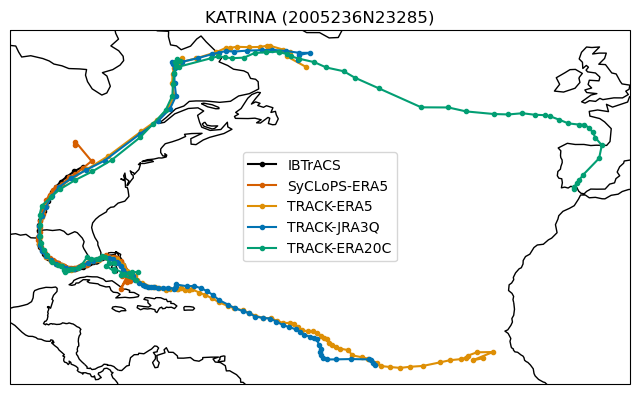

In [53]:
plot_composite(eib, "2005236N23285") 

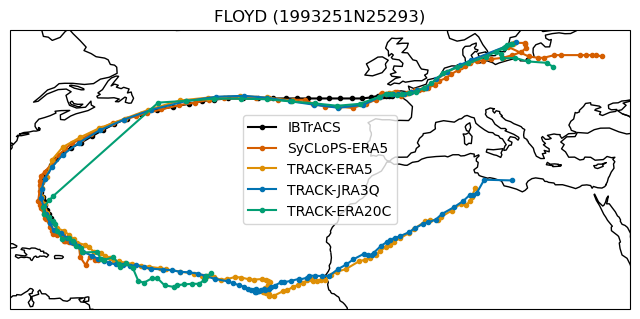

In [54]:
plot_composite(eib, "1993251N25293") 